## Graph 1

In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph
# framework that helps design and manage the flow of tasks in your application using a graph

In [2]:
# Create an AgentState - shared data structure that keeps track of information as your app runs
class AgentState(TypedDict):
    message: str

def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] = "Hey " + state['message'] + ", how is your day going?"
    return state

In [3]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

In [22]:
from IPython.display import Image, display

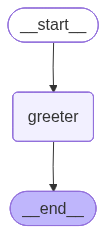

In [5]:
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke({"message": "Bob"})

In [7]:
result['message']

'Hey Bob, how is your day going?'

## Graph 2

In [8]:
from typing import List

In [9]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

def process_values(state: AgentState) -> AgentState: 
    """This function handles multiple different inputs"""

    state["result"] = f"Hi there {state["name"]}! Your sum = {sum(state["values"])}"
    return state

In [10]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)

graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

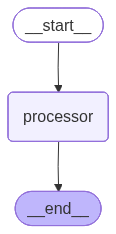

In [11]:
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
result = app.invoke({"values": [1,2,3,4], "name": "Steve"})

In [13]:
print(result['result'])

Hi there Steve! Your sum = 10


### Exercise

In [14]:
import numpy as np

class AgentState(TypedDict):
    values: List[int]
    name: str
    operation: str
    result: str

def process_values(state: AgentState) -> AgentState: 
    """This function handles multiple different inputs"""
    
    if state['operation'] == '+':
        answer = sum(state['values'])
    elif state['operation'] == '*':
        answer = np.prod(state['values'])
    else:
        answer = 'invalid'
    state['result'] = f"Hi there {state["name"]}! Your answer is {answer}"
    return state

In [15]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)

graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

In [16]:
result = app.invoke({"values": [1,2,3,4], "name": "Steve", "operation": "+"})

In [17]:
print(result['result'])

Hi there Steve! Your answer is 10


In [18]:
result = app.invoke({"values": [1,2,3,4], "name": "Steve", "operation": "*"})

In [19]:
print(result['result'])

Hi there Steve! Your answer is 24


In [20]:
result = app.invoke({"values": [1,2,3,4], "name": "Steve", "operation": ""})

In [21]:
print(result['result'])

Hi there Steve! Your answer is invalid


## Graph 3

In [22]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [28]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""

    state['final'] = f"Hi {state['name']}!"
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence"""

    state['final'] = state['final'] + f" You are {state['age']} years old"
    return state

In [29]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.set_finish_point("second_node")

app = graph.compile()

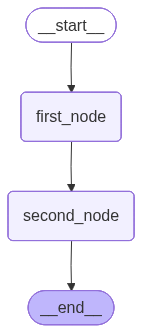

In [30]:
display(Image(app.get_graph().draw_mermaid_png()))

In [31]:
result = app.invoke({"name": "Charlie", "age": 20})

In [32]:
print(result)

{'name': 'Charlie', 'age': 20, 'final': 'Hi Charlie! You are 20 years old'}


### Exercise

In [33]:
class AgentState(TypedDict):
    name: str
    age: str
    skills: List[str]
    final: str

In [34]:
def first_node(state: AgentState) -> AgentState:
    """This node will greet the user"""

    state['final'] = f"Hi {state['name']}!"
    return state

def second_node(state: AgentState) -> AgentState:
    """This node will describe the user's age"""

    state['final'] = state['final'] + f" You are {state['age']} years old."
    return state

def third_node(state: AgentState) -> AgentState:
    """This node will list the user's skills in a formatted string"""

    state['final'] = state['final'] + f" You have skills in: {", ".join(state['skills'])}"
    return state

In [35]:
graph = StateGraph(AgentState)

graph.add_node("personalize", first_node)
graph.add_node("age_description", second_node)
graph.add_node("skills_description", third_node)

graph.set_entry_point("personalize")
graph.add_edge("personalize", "age_description")
graph.add_edge("age_description", "skills_description")
graph.set_finish_point("skills_description")

app = graph.compile()

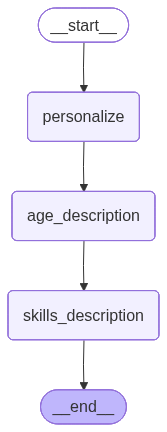

In [36]:
display(Image(app.get_graph().draw_mermaid_png()))

In [37]:
result = app.invoke({"name": "Charlie", "age": 20, "skills": ['Python', 'Machine Learning']})

In [38]:
print(result['final'])

Hi Charlie! You are 20 years old. You have skills in: Python, Machine Learning


## Graph 4

In [39]:
from langgraph.graph import START, END

In [40]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    final: int

In [41]:
def adder(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state['final'] = state['number1'] + state['number2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""

    state['final'] = state['number1'] - state['number2']
    return state

def decider(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state['operation'] == "+":
        return "addition_operation"
    elif state['operation'] == "-":
        return "subtraction_operation"


In [42]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state) #passthrough function

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router", decider,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)
graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

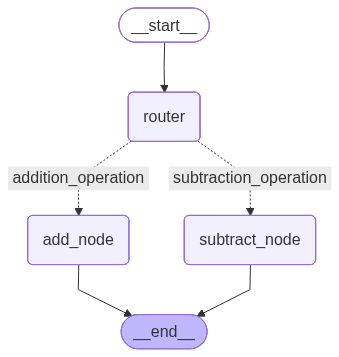

In [43]:
display(Image(app.get_graph().draw_mermaid_png()))

In [44]:
state1 = AgentState(number1 = 10, operation = "-", number2 = 5)
print(app.invoke(state1))

{'number1': 10, 'operation': '-', 'number2': 5, 'final': 5}


In [45]:
state1 = AgentState(number1 = 10, operation = "+", number2 = 5)
print(app.invoke(state1))

{'number1': 10, 'operation': '+', 'number2': 5, 'final': 15}


### Exercise

In [46]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation: str
    operation2: str
    final: int
    final2: int

In [47]:
def adder(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state['final'] = state['number1'] + state['number2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""

    state['final'] = state['number1'] - state['number2']
    return state

def decider(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state['operation'] == "+":
        return "addition_operation"
    elif state['operation'] == "-":
        return "subtraction_operation"
        
def adder2(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state['final2'] = state['number3'] + state['number4']
    return state

def subtractor2(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""

    state['final2'] = state['number3'] - state['number4']
    return state

def decider2(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state['operation2'] == "+":
        return "addition_operation2"
    elif state['operation2'] == "-":
        return "subtraction_operation2"

In [48]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router", lambda state:state) #passthrough function
graph.add_node("router2", lambda state:state) #passthrough function

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router", decider,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")

graph.add_conditional_edges(
    "router2", decider2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

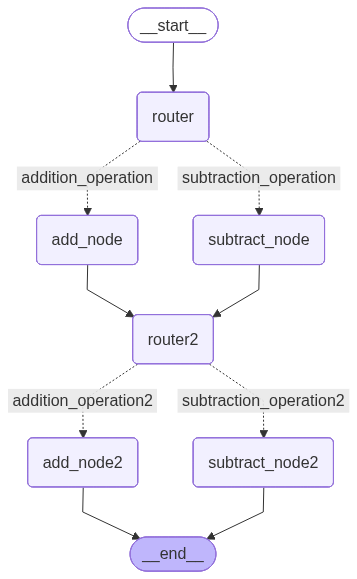

In [49]:
display(Image(app.get_graph().draw_mermaid_png()))

In [50]:
state1 = AgentState(number1 = 10, number2 = 5, number3 = 7, number4 = 2,
                    operation = "-", operation2 = "+",
                    final = 0, final2 = 0)
print(app.invoke(state1))

{'number1': 10, 'number2': 5, 'number3': 7, 'number4': 2, 'operation': '-', 'operation2': '+', 'final': 5, 'final2': 9}


## Graph 5

In [51]:
import random

In [52]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [53]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node which says hi to the person"""

    state['name'] = f"Hi there, {state['name']}"
    state['counter'] = 0
    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""

    state['number'].append(random.randint(0,10))
    state['counter'] += 1
    return state

def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""

    if state['counter'] < 5:
        print("ENTERING LOOP", state['counter'])
        return "loop" # continue looping
    else:
        return "exit" # exit loop

In [54]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)


graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random", should_continue,
    {
        "loop": "random",
        "exit": END
    }
)

app = graph.compile()

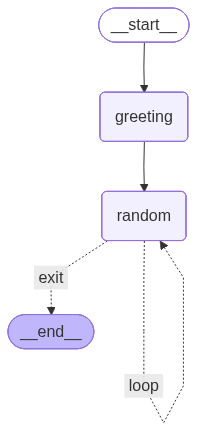

In [55]:
display(Image(app.get_graph().draw_mermaid_png()))

In [59]:
app.invoke({"name": "George", "number": [], "counter": -2})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, George', 'number': [4, 8, 3, 2, 3], 'counter': 5}

### Exercise

In [60]:
class AgentState(TypedDict):
    name: str
    guesses: List[int]
    attempts: int
    lower: int
    upper: int
    answer: int

In [61]:
def setup_node(state: AgentState) -> AgentState:
    """Setup Node which says hi to the person, initialises upper/lower bounds
    and generates random answer to be guessed"""

    state['name'] = f"Hi there, {state['name']}"
    state['attempts'] = 0
    state['lower'] = 1
    state['upper'] = 20
    state['answer'] = random.randint(state['lower'], state['upper'])
    print(f"{state['name']} The game has begun. I'm thinking of a number between 1 and 20.")
    return state

def guess_node(state: AgentState) -> AgentState:
    """Generates a random number from lower bound to upper bound as a guess"""
    guess = random.randint(state['lower'], state['upper'])
    state['guesses'].append(guess)
    state['attempts'] += 1
    print(f"Attempt {state['attempts']}: Guessing {guess} (Current range: {state['lower']}-{state['upper']})")
    return state

def should_continue(state: AgentState) -> AgentState:
    """Function to decide whether to continue guessing or to end"""
    if state['answer'] in state['guesses']:
        print(f"GAME OVER: Number found!")
        return "exit"
    else:
        if state['attempts'] < 7:
            print(f"CONTINUING: {state['attempts']}/7 attempts used")
            return "continue" # continue looping
        else:
            print(f"GAME OVER: Maximum attempts reached! The number was {state['answer']}")
            return "exit" # exit loop

def hint_node(state: AgentState) -> AgentState:
    """Function to give hints by updating lower/upper bounds"""
    
    if state['guesses'][-1] < state['answer']:
        state['lower'] = state['guesses'][-1] + 1
        print(f"The number {state['guesses'][-1]} is too low. Try higher!")
    elif state['guesses'][-1] > state['answer']:
        state['upper'] = state['guesses'][-1] - 1
        print(f"The number {state['guesses'][-1]} is too high. Try lower!")
    return state

In [62]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint", hint_node)


graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")

graph.add_conditional_edges(
    "hint", should_continue,
    {
        "continue": "guess",
        "exit": END
    }
)

app = graph.compile()

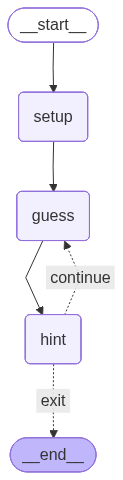

In [63]:
display(Image(app.get_graph().draw_mermaid_png()))

In [65]:
result = app.invoke({"name": "Brinjal", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})
print(result['answer'])

Hi there, Brinjal The game has begun. I'm thinking of a number between 1 and 20.
Attempt 1: Guessing 1 (Current range: 1-20)
The number 1 is too low. Try higher!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 14 (Current range: 2-20)
The number 14 is too low. Try higher!
CONTINUING: 2/7 attempts used
Attempt 3: Guessing 20 (Current range: 15-20)
The number 20 is too high. Try lower!
CONTINUING: 3/7 attempts used
Attempt 4: Guessing 16 (Current range: 15-19)
The number 16 is too low. Try higher!
CONTINUING: 4/7 attempts used
Attempt 5: Guessing 19 (Current range: 17-19)
The number 19 is too high. Try lower!
CONTINUING: 5/7 attempts used
Attempt 6: Guessing 18 (Current range: 17-18)
GAME OVER: Number found!
18


## Agent 1 (Basic Bot)

In [66]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
#from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END

In [2]:
import os
import getpass

#os.environ['OPENAI_API_KEY'] = getpass.getpass()
os.environ["GOOGLE_API_KEY"] = getpass.getpass()

 ········


In [68]:
class AgentState(TypedDict):
    messages: List[HumanMessage]

In [69]:
#llm = ChatOpenAI(model="gpt-4o")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [70]:
def process(state: AgentState) -> AgentState:
    response = llm.invoke(state['messages'])
    print(f"\nAI: {response.content}")
    return state

In [71]:
graph = StateGraph(AgentState)

graph.add_node("process", process)

graph.add_edge(START, "process")
graph.add_edge("process", END)

agent = graph.compile()

In [18]:
# LLM does not have memory

user_input = input("Enter: ")
while user_input != "exit":
    agent.invoke({"messages": [HumanMessage(content=user_input)]})
    user_input = input("Enter: ")

Enter:  My name is Bob



AI: Hello Bob! It's nice to meet you. How can I help you today?


Enter:  What is my name?



AI: I do not have access to your personal information, including your name. I am a large language model, and I am not designed to collect or store user data.


Enter:  exit


## Agent 2 (Memory)

In [72]:
from typing import Union
from langchain_core.messages import AIMessage

In [73]:
class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]]

In [74]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [75]:
def process(state: AgentState) -> AgentState:
    """This node will solve the request you input"""
    
    response = llm.invoke(state['messages'])
    state['messages'].append(AIMessage(content=response.content))
    print(f"\nAI: {response.content}")
    return state

In [76]:
graph = StateGraph(AgentState)

graph.add_node("process", process)

graph.add_edge(START, "process")
graph.add_edge("process", END)

agent = graph.compile()

In [24]:
conversation_history = []

user_input = input("Enter: ")
while user_input != "exit":
    conversation_history.append(HumanMessage(content=user_input))
    result = agent.invoke({"messages": conversation_history})
    conversation_history = result['messages']
    user_input = input("Enter: ")

Enter:  My name is Bob



AI: Hello Bob! It's nice to meet you. How can I help you today?


Enter:  What is my name?



AI: Your name is Bob.


Enter:  exit


In [25]:
# Save conversation to text file

with open("logging.txt", "w") as file:
    file.write("Your Conversation Log:\n")
    
    for message in conversation_history:
        if isinstance(message, HumanMessage):
            file.write(f"You: {message.content}\n")
        elif isinstance(message, AIMessage):
            file.write(f"AI: {message.content}\n\n")
    file.write("End of Conversation")

print("Conversation saved to logging.txt")

Conversation saved to logging.txt


## Agent 3 (ReAct - Reasoning and Acting)

In [77]:
from typing import Annotated, Sequence
# Annotated - Provides additional context without affecting the type itself
# Sequence - Automatically handles the state updates for sequences such as by adding new messages to a chat history
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
# add_messages - Reducer Function (Rule that controls how updates from nodes are combined with the existing state.
#                                  Tells us how to merge new data into the current state
#                                  Without a reducer, updates would have replaced the existing value entirely)
from langgraph.prebuilt import ToolNode

In [27]:
# Without Reducer
# state = {'messages': ["Hi!"]}
# update = {'messages': ["Nice to meet you!"]}
# new_state = {'messages': ["Nice to meet you!"]}

# With Reducer
# state = {'messages': ["Hi!"]}
# update = {'messages': ["Nice to meet you!"]}
# new_state = {'messages': ["Hi!", "Nice to meet you!"]}

In [78]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [79]:
@tool
def add(a: int, b: int):
    """This is an additiona function that adds 2 numbers together"""

    return a + b

@tool
def subtract(a: int, b: int):
    """Subtraction function"""
    return a - b

@tool
def multiply(a: int, b: int):
    """Multiplication function"""
    return a * b

In [80]:
tools = [add, subtract, multiply]

In [81]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite").bind_tools(tools)

In [82]:
def model_call(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content = "You are my AI assistant, please answer my query to the best of your ability.")
    response = llm.invoke([system_prompt] + state['messages'])
    return {"messages": [response]}

In [83]:
def should_continue(state: AgentState):
    messages = state['messages']
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

In [84]:
graph = StateGraph(AgentState)

graph.add_node("agent", model_call)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.add_edge(START, "agent")
graph.add_conditional_edges(
    "agent", should_continue,
    {
        "continue": "tools",
        "end": END
    }
)
graph.add_edge("tools", "agent")

app = graph.compile()

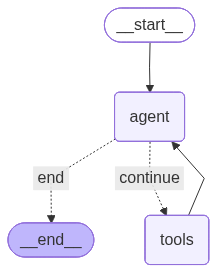

In [85]:
display(Image(app.get_graph().draw_mermaid_png()))

In [86]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

In [75]:
inputs = {"messages": [("user", "Add 40 + 12 and then multiply the result by 6 and tell me a joke.")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 40 + 12 and then multiply the result by 6 and tell me a joke.
================================== Ai Message ==================================
Tool Calls:
  add (8555a174-e47b-450a-aeb1-c6fbb6e81577)
 Call ID: 8555a174-e47b-450a-aeb1-c6fbb6e81577
  Args:
    a: 40
    b: 12
  multiply (55bb1e34-bf7c-40e6-94e2-20992f626b19)
 Call ID: 55bb1e34-bf7c-40e6-94e2-20992f626b19
  Args:
    a: 52
    b: 6
================================= Tool Message =================================
Name: multiply

312
================================== Ai Message ==================================

Here's a joke for you: Why don’t scientists trust atoms? Because they make up everything!


## Agent 4 (Drafter)

In [14]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv  
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [22]:
document_content = ""

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [23]:
@tool
def update(content: str) -> str:
    """Updates the document with the provided content"""

    global document_content
    document_content = content
    return f"Document has been updated successfully! The current content is:\n{document_content}"

@tool
def save(filename: str) -> str:
    """Save the current document to a text file and finish the process.
    
    Args:
        filename: Name for the text file.
    """

    if not filename.endswith('.txt'):
        filename = f"{filename}.txt"

    try:
        with open(filename, 'w') as file:
            file.write(document_content)
        print(f"\n💾 Document has been saved to: {filename}")
        return f"Document has been saved successfully to '{filename}'."
    
    except Exception as e:
        return f"Error saving document: {str(e)}"

In [24]:
tools = [update, save]

In [25]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite").bind_tools(tools)

In [26]:
def our_agent(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content=f"""
    You are Drafter, a helpful writing assistant. You are going to help the user update and modify documents.
    
    - If the user wants to update or modify content, use the 'update' tool with the complete updated content.
    - If the user wants to save and finish, you need to use the 'save' tool.
    - Make sure to always show the current document state after modifications.
    
    The current document content is:{document_content}
    """)

    if not state["messages"]:
        user_input = "I'm ready to help you update a document. What would you like to create?"
        user_message = HumanMessage(content=user_input)
    else:
        user_input = input("\nWhat would you like to do with the document? ")
        print(f"\n👤 USER: {user_input}")
        user_message = HumanMessage(content=user_input)
    
    all_messages = [system_prompt] + list(state["messages"]) + [user_message]

    response = model.invoke(all_messages)

    print(f"\n🤖 AI: {response.content}")
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"🔧 USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")

    return {"messages": list(state["messages"]) + [user_message, response]}

In [27]:
def should_continue(state: AgentState) -> str:
    """Determine if we should continue or end the conversation."""

    messages = state["messages"]
    
    if not messages:
        return "continue"
    
    # This looks for the most recent tool message....
    for message in reversed(messages):
        # ... and checks if this is a ToolMessage resulting from save
        if (isinstance(message, ToolMessage) and 
            "saved" in message.content.lower() and
            "document" in message.content.lower()):
            return "end" # goes to the end edge which leads to the endpoint
        
    return "continue"

In [28]:
def print_messages(messages):
    """Function I made to print the messages in a more readable format"""
    if not messages:
        return
    
    for message in messages[-3:]:
        if isinstance(message, ToolMessage):
            print(f"\n🛠️ TOOL RESULT: {message.content}")

In [29]:
graph = StateGraph(AgentState)

graph.add_node("agent", our_agent)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "agent")
graph.add_edge("agent", "tools")
graph.add_conditional_edges(
    "tools", should_continue,
    {
        "continue": "agent",
        "end": END
    }
)

app = graph.compile()

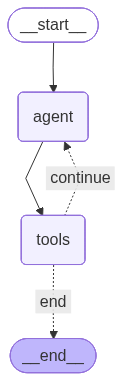

In [17]:
display(Image(app.get_graph().draw_mermaid_png()))

In [30]:
def run_document_agent():
    print("\n ===== DRAFTER =====")
    
    state = {"messages": []}
    
    for step in app.stream(state, stream_mode="values"):
        if "messages" in step:
            print_messages(step["messages"])
    
    print("\n ===== DRAFTER FINISHED =====")

In [31]:
run_document_agent()


 ===== DRAFTER =====

🤖 AI: I'm ready to help you update a document. What would you like to create?



What would you like to do with the document?  Write me an email.



👤 USER: Write me an email.

🤖 AI: I can help with that. What is the email about? What are the key points you want to include? Who is the recipient?



What would you like to do with the document?  Tell Tom that I cannot make it to the meeting.



👤 USER: Tell Tom that I cannot make it to the meeting.

🤖 AI: 
🔧 USING TOOLS: ['update']

🛠️ TOOL RESULT: Document has been updated successfully! The current content is:
I am writing to inform you that I will not be able to attend the meeting. I apologize for any inconvenience this may cause.


...


👤 USER: My name is Bob

🤖 AI: 
🔧 USING TOOLS: ['update']

🛠️ TOOL RESULT: Document has been updated successfully! The current content is:
Hi Tom,

I am writing to inform you that I will not be able to attend the 10 AM meeting at Canary Wharf. I apologize for any inconvenience this may cause.

Best regards,

🛠️ TOOL RESULT: Document has been updated successfully! The current content is:
Hi Tom,

I am writing to inform you that I will not be able to attend the 10 AM meeting at Canary Wharf. I apologize for any inconvenience this may cause.

Best regards,
Bob



What would you like to do with the document?  Let him know that I can make it at 12PM at New York the next day.



👤 USER: Let him know that I can make it at 12PM at New York the next day.

🤖 AI: 
🔧 USING TOOLS: ['update']

🛠️ TOOL RESULT: Document has been updated successfully! The current content is:
Hi Tom,

I am writing to inform you that I will not be able to attend the 10 AM meeting at Canary Wharf. I apologize for any inconvenience this may cause.

Best regards,
Bob

🛠️ TOOL RESULT: Document has been updated successfully! The current content is:
Hi Tom,

I am writing to inform you that I will not be able to attend the 10 AM meeting at Canary Wharf. I can make it at 12 PM in New York the next day. I apologize for any inconvenience this may cause.

Best regards,
Bob



What would you like to do with the document?  exit



👤 USER: exit

🤖 AI: 
🔧 USING TOOLS: ['save']

🛠️ TOOL RESULT: Document has been updated successfully! The current content is:
Hi Tom,

I am writing to inform you that I will not be able to attend the 10 AM meeting at Canary Wharf. I can make it at 12 PM in New York the next day. I apologize for any inconvenience this may cause.

Best regards,
Bob

💾 Document has been saved to: email.txt

🛠️ TOOL RESULT: Document has been saved successfully to 'email.txt'.

 ===== DRAFTER FINISHED =====


## Agent 5 (RAG)

In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool

In [3]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)

In [4]:
# Embedding Model - has to also be compatible with the LLM
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

In [5]:
pdf_path = "Stock_Market_Performance_2024.pdf"

In [6]:
# Safety measure for debugging purposes
if not os.path.exists(pdf_path):
    raise FileNotFoundError(f"PDF file not found: {pdf_path}")

pdf_loader = PyPDFLoader(pdf_path) # This loads the PDF

In [7]:
# Checks if the PDF is there
try:
    pages = pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise

PDF has been loaded and has 9 pages


In [8]:
# Chunking Process
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [9]:
pages_split = text_splitter.split_documents(pages) # We now apply this to our pages

persist_directory = r"C:\Users\cherw\Desktop\Projects\GenAI\chroma_langchain_db"
collection_name = "stock_market"

# If our collection does not exist in the directory, we create using the os command
if not os.path.exists(persist_directory):
    os.makedirs(persist_directory)

In [10]:
try:
    # Here, we actually create the chroma database using our embeddigns model
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name=collection_name
    )
    print(f"Created ChromaDB vector store!")
    
except Exception as e:
    print(f"Error setting up ChromaDB: {str(e)}")
    raise

Created ChromaDB vector store!


In [11]:
# Now we create our retriever 
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5} # K is the amount of chunks to return
)

In [12]:
@tool
def retriever_tool(query: str) -> str:
    """
    This tool searches and returns the information from the Stock Market Performance 2024 document.
    """

    docs = retriever.invoke(query)

    if not docs:
        return "I found no relevant information in the Stock Market Performance 2024 document."
    
    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i+1}:\n{doc.page_content}")
    
    return "\n\n".join(results)

In [13]:
tools = [retriever_tool]

llm = llm.bind_tools(tools)

In [14]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [15]:
def should_continue(state: AgentState):
    """Check if the last message contains tool calls."""
    result = state['messages'][-1]
    return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0

In [16]:
system_prompt = """
You are an intelligent AI assistant who answers questions about Stock Market Performance in 2024 based on the PDF document loaded into your knowledge base.
Use the retriever tool available to answer questions about the stock market performance data. You can make multiple calls if needed.
If you need to look up some information before asking a follow up question, you are allowed to do that!
Please always cite the specific parts of the documents you use in your answers.
"""

In [17]:
tools_dict = {our_tool.name: our_tool for our_tool in tools} # Creating a dictionary of our tools

In [18]:
# LLM Agent
def call_llm(state: AgentState) -> AgentState:
    """Function to call the LLM with the current state."""
    messages = list(state['messages'])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm.invoke(messages)
    return {'messages': [message]}

In [19]:
# Retriever Agent
def take_action(state: AgentState) -> AgentState:
    """Execute tool calls from the LLM's response."""

    tool_calls = state['messages'][-1].tool_calls
    results = []
    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}")
        
        if not t['name'] in tools_dict: # Checks if a valid tool is present
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."
        
        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")
            

        # Appends the Tool Message
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {'messages': results}

In [20]:
graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("retriever_agent", take_action)

graph.add_conditional_edges(
    "llm",
    should_continue,
    {True: "retriever_agent", False: END}
)
graph.add_edge("retriever_agent", "llm")
graph.set_entry_point("llm")

rag_agent = graph.compile()

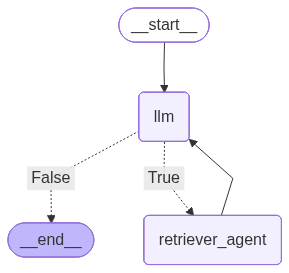

In [24]:
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [25]:
def running_agent():
    print("\n=== RAG AGENT===")
    
    while True:
        user_input = input("\nWhat is your question: ")
        if user_input.lower() in ['exit', 'quit']:
            break
            
        messages = [HumanMessage(content=user_input)] # converts back to a HumanMessage type

        result = rag_agent.invoke({"messages": messages})
        
        print("\n=== ANSWER ===")
        print(result['messages'][-1].content)

In [26]:
running_agent()


=== RAG AGENT===



What is your question:  How was the SNP500 performing in 2024?


Calling Tool: retriever_tool with query: SNP500 performance in 2024
Result length: 4867
Tools Execution Complete. Back to the model!

=== ANSWER ===
The S&P 500 index had a strong performance in 2024, delivering a total return of approximately 25% (around 23% in price terms). This marks the second consecutive year of over 20% returns for the index, a performance not seen since the late 1990s. The rally was largely driven by mega-cap technology stocks, with a group of seven companies, including Apple, Microsoft, Alphabet, Amazon, Meta, Nvidia, and Tesla, collectively surging by about 64-67% on average. These companies accounted for over half of the S&P 500's gains for the year.



What is your question:  where did you retrieve this information from?



=== ANSWER ===
I retrieved this information from the Stock Market Performance 2024 document.



What is your question:  which part?



=== ANSWER ===
I need more context to answer your question. Please tell me what you are referring to. What information are you looking for?



What is your question:  OpenAI stock performance?


Calling Tool: retriever_tool with query: OpenAI stock performance
Result length: 4766
Tools Execution Complete. Back to the model!

=== ANSWER ===
I am sorry, but I cannot find any information about OpenAI's stock performance in the provided documents. The documents mention other tech companies like Palantir Technologies, Alphabet, Amazon, Meta, and Tesla, along with general market trends.



What is your question:  exit
